In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split,learning_curve,GridSearchCV,cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,roc_auc_score,roc_curve
import warnings
warnings.filterwarnings("ignore")
import joblib
import streamlit as st
import pickle

In [4]:
df = pd.read_csv("Telco_Customer_Churn.csv")

In [5]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [7]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [8]:
df.duplicated().sum()

0

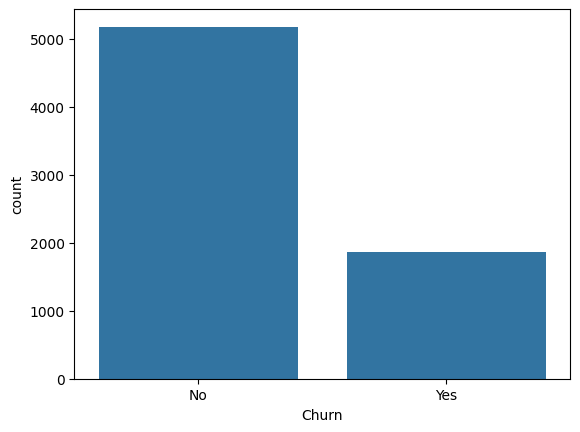

In [9]:
sns.countplot(x="Churn",data=df)
plt.show()

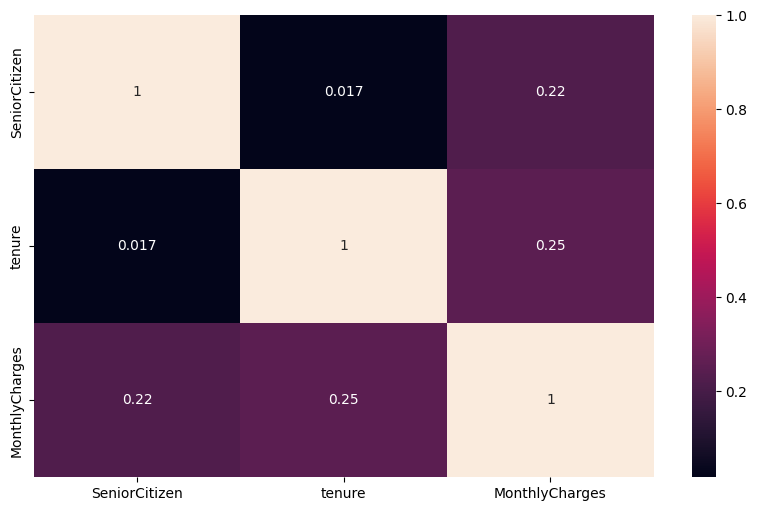

In [10]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True),annot=True)
plt.show()

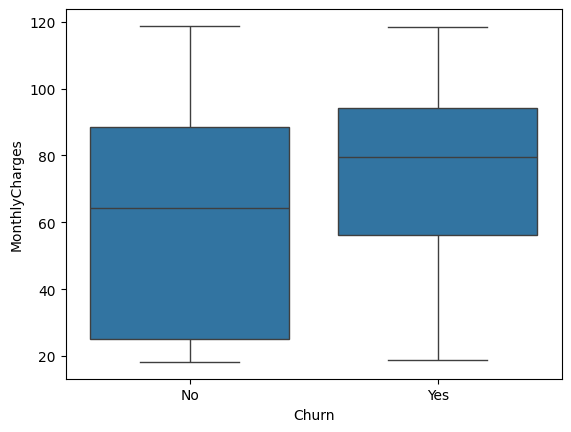

In [11]:
sns.boxplot(x="Churn",y="MonthlyCharges",data=df)
plt.show()

In [12]:
x=df.drop(["Churn","customerID"],axis=1)
y=df["Churn"].map({"No":0,"Yes":1})

In [13]:
y.isnull().sum()

0

In [14]:
most_frequent=y.mode()[0]
y=y.fillna(most_frequent)

In [15]:
y.isnull().sum()

0

In [16]:
print(df["Churn"].unique())

['No' 'Yes']


In [17]:
num_cols=x.select_dtypes(include=["int64","float64"]).columns

In [18]:
cat_cols=x.select_dtypes(include=["object","category"]).columns

In [19]:
num_pipeline=Pipeline(steps=[
    ("imputer",SimpleImputer(strategy="median")),
    ("scaler",StandardScaler())
])

In [20]:
cat_pipeline=Pipeline(steps=[
    ("imputer",SimpleImputer(strategy="most_frequent")),
    ("encoder",OneHotEncoder(handle_unknown="ignore",sparse_output=False))
])

In [21]:
preprocessor = ColumnTransformer(transformers=[
    ("num",num_pipeline,num_cols),
    ("cat",cat_pipeline,cat_cols)
])

In [22]:
model_lg = Pipeline(steps=[
    ("preprocessor",preprocessor),
    ("classifier",LogisticRegression(class_weight="balanced",max_iter=1000))
])

In [23]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

In [24]:
model_lg.fit(x_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['SeniorCitizen', 'tenure', 'MonthlyCharges'], dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'TotalCharges'],
      dtype='object'))])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

In [25]:
y_pred = model_lg.predict(x_test)

In [26]:
print("\n Accuracy score")
print(accuracy_score(y_test,y_pred))


 Accuracy score
0.7530163236337828


In [27]:
print("\n Confusion matrix")
print(confusion_matrix(y_test,y_pred))


 Confusion matrix
[[777 258]
 [ 90 284]]


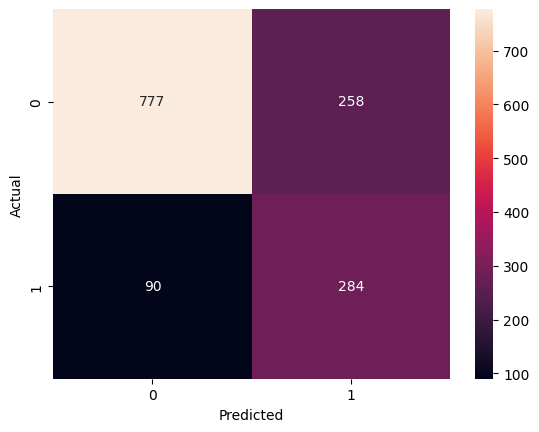

In [28]:
cm=confusion_matrix(y_test,y_pred)
sns.heatmap(cm,annot=True,fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [29]:
print("\n Classification report")
print(classification_report(y_pred,y_test))


 Classification report
              precision    recall  f1-score   support

           0       0.75      0.90      0.82       867
           1       0.76      0.52      0.62       542

    accuracy                           0.75      1409
   macro avg       0.76      0.71      0.72      1409
weighted avg       0.75      0.75      0.74      1409



In [30]:
y_prob_lg = model_lg.predict_proba(x_test)[:,1]
roc_score = roc_auc_score(y_test,y_prob_lg)
print("ROC-AUC-Score: ",roc_score)

ROC-AUC-Score:  0.8400630344364359


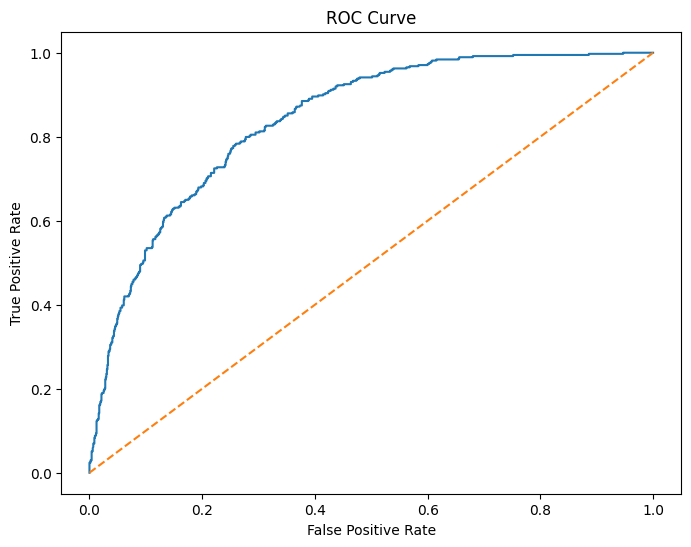

In [31]:
fpr,tpr,thresholds = roc_curve(y_test,y_prob_lg)
plt.figure(figsize=(8,6))
plt.plot(fpr,tpr)
plt.plot([0,1],[0,1],linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

In [32]:
model_rfc = Pipeline(steps=[
    ("preprocessor",preprocessor),
    ("classifier",RandomForestClassifier(class_weight="balanced",random_state=42))
])

In [33]:
model_rfc.fit(x_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['SeniorCitizen', 'tenure', 'MonthlyCharges'], dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'TotalCharges'],
      dtype='object'))])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced',
                                        random_state=42))])

In [34]:
param_grid={
    "classifier__n_estimators":[100,200],
    "classifier__max_depth":[3,5,7],
    "classifier__min_samples_split":[5,10,20],
    "classifier__min_samples_leaf":[2,4,8]
}

In [35]:
grid_search=GridSearchCV(
    model_rfc,
    param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

In [36]:
grid_search.fit(x_train,y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         Index(['SeniorCitizen', 'tenure', 'MonthlyCharges'], dtype='object')),
                                                                        ('cat',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('encoder',
                                                                                          OneHotE...
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'TotalCharges'],
      dtype='object'))])),
                                       ('classifier',
                                        RandomForestClassifier(class_weight='balanced',
                                                               random_state=42))]),
             n_jobs=-1,
             param_grid={'classifier__max_depth': [3, 5, 7],
                         'classifier__min_samples_leaf': [2, 4, 8],
                         'classifier__min_samples_split': [5, 10, 20],
                         'classifier__n_estimators': [100, 200]},
             scoring='f1')

In [37]:
print(grid_search.best_params_)

{'classifier__max_depth': 3, 'classifier__min_samples_leaf': 8, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 200}


In [38]:
best_model = grid_search.best_estimator_

In [39]:
rfc_pred = best_model.predict(x_test)
print(classification_report(y_test,rfc_pred))

              precision    recall  f1-score   support

           0       0.91      0.63      0.75      1035
           1       0.45      0.83      0.58       374

    accuracy                           0.68      1409
   macro avg       0.68      0.73      0.66      1409
weighted avg       0.79      0.68      0.70      1409



In [40]:
train_pred = best_model.predict(x_train)
train_acc =accuracy_score(
    y_train,train_pred
)
print("Training Accuracy: ",train_acc)

Training Accuracy:  0.7003904863329783


In [41]:
test_pred = best_model.predict(x_test)
test_acc = accuracy_score(y_test,test_pred)
print("Testing Accuracy: ",test_acc)

Testing Accuracy:  0.6841731724627396


In [42]:
print("Difference: ",train_acc-test_acc)

Difference:  0.016217313870238725


In [43]:
y_prob = best_model.predict_proba(x_test)[:,1]
roc_score=roc_auc_score(y_test,y_prob)
print("ROC curve:",roc_score)

ROC curve: 0.8033751840657212


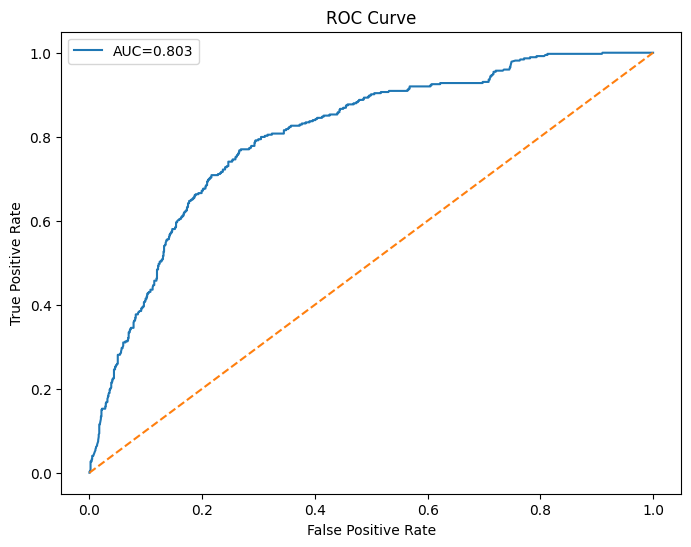

In [44]:
fpr,tpr,thresholds=roc_curve(y_test,y_prob)
plt.figure(figsize=(8,6))
plt.plot(fpr,tpr,label=f"AUC={roc_score:.3f}")
plt.plot([0,1],[0,1],linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [45]:
cv_score=cross_val_score(
    best_model,x,y,cv=5,scoring="f1"
)
print("\n Cross valudation score")
print(cv_score)
print("\n Average Cross validation score")
print(cv_score.mean())



 Cross valudation score
[0.61835749 0.61132812 0.58891013 0.59856997 0.58301887]

 Average Cross validation score
0.6000369168093864


In [46]:
rf_classifier=best_model.named_steps["classifier"]
importance=rf_classifier.feature_importances_
feature_names=best_model.named_steps[
    "preprocessor"
].get_feature_names_out()
importance_df=pd.DataFrame({
    "Feature":feature_names,
    "Importance":importance
})
importance_df=importance_df.sort_values(
    by="Importance",
    ascending=False
)
print(importance_df.head(10))

                                       Feature  Importance
30        cat__StreamingTV_No internet service    0.067077
24   cat__DeviceProtection_No internet service    0.049571
1                                  num__tenure    0.046064
35                cat__Contract_Month-to-month    0.044468
17                      cat__OnlineSecurity_No    0.044183
42         cat__PaymentMethod_Electronic check    0.038686
41  cat__PaymentMethod_Credit card (automatic)    0.034962
2                          num__MonthlyCharges    0.034458
23                    cat__DeviceProtection_No    0.034362
11                       cat__MultipleLines_No    0.032626


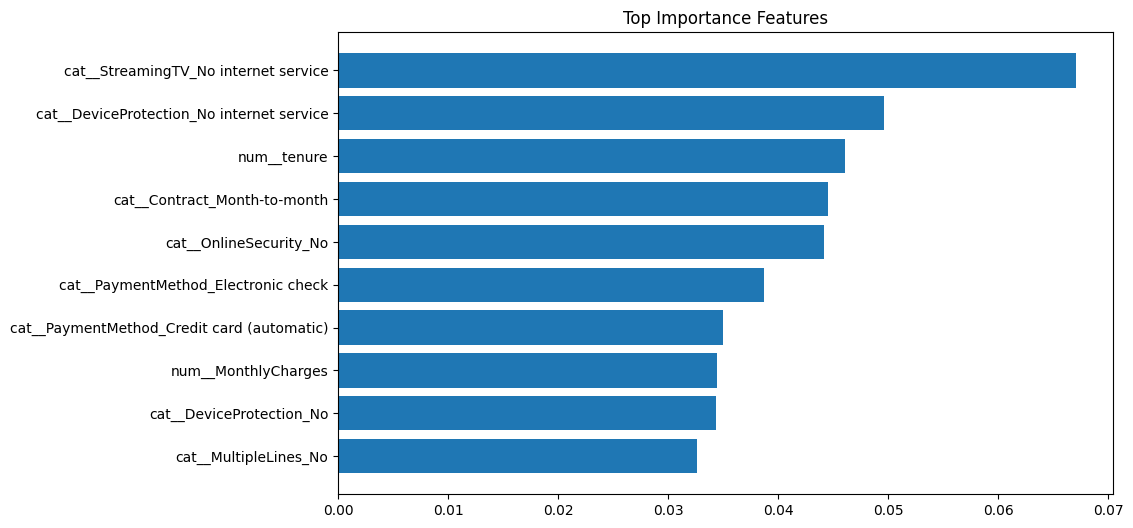

In [47]:
top_features=importance_df.head(10)
plt.figure(figsize=(10,6))
plt.barh(top_features["Feature"],top_features["Importance"])
plt.gca().invert_yaxis()
plt.title("Top Importance Features")
plt.show()

In [48]:
train_pred=best_model.predict(x_train)
train_acc=accuracy_score(y_train,train_pred)
test_pred=best_model.predict(x_test)
test_acc=accuracy_score(y_test,test_pred)
print("Train Accuracy:",train_acc)
print("Test Accuracy:",test_acc)
print("Difference:",train_acc,test_acc)

Train Accuracy: 0.7003904863329783
Test Accuracy: 0.6841731724627396
Difference: 0.7003904863329783 0.6841731724627396


In [49]:
import joblib
joblib.dump(model_lg,"first_model.joblib",compress=3)
print("Model Saved Successefully")

Model Saved Successefully


In [50]:
%%writefile app.py
import streamlit as st
import pandas as pd
import joblib
model=joblib.load("first_model.joblib")
st.set_page_config(page_title="Churn Prediction")
st.title("Customer Churn Prediction")
# st.write("Predict whethe a customer is likely to churn")
# st.markdown("--")
gender=st.selectbox("Gender",["Male","Female"])
SeniorCitizen=st.selectbox("Senior Citizen",[0,1])
Partner=st.selectbox("Partner",["Yes","No"])
Dependents=st.selectbox("Dependents",["Yes","No"])
tenure=st.slider("tenure",0,72,12)
PhoneService=st.selectbox("Phone Service",["Yes","No"])
MultipleLines=st.selectbox("Multi Plelines",["Yes","No","No Phone Service"])
InternetService=st.selectbox("Internet Service",["DSL","Fibre optic","No"])
OnlineSecurity=st.selectbox("Online Security",["Yes","No","No internet service"])
OnlineBackup=st.selectbox("Online Backup",["Yes","No","No ineternet service"])
DeviceProtection=st.selectbox("Device Protection",["Yes","No","ineternet service"])
TechSupport=st.selectbox("Tech Support",["Yes","No","No internet servce"])
StreamingTV=st.selectbox("Streaming TV",["Yes","No","internet service "])
StreamingMovies=st.selectbox("Streaming Movies",["Yes","No","internet service"])
PaperlessBilling=st.selectbox("Paperless Billing",["Yes","No"])
PaymentMethod=st.selectbox("Payment methods",["Electronic check","Mailed check","Bank transfer(automatic)","credit card(automatic)"])
MonthlyCharges=st.number_input("Monthly Charges",min_value=0.0)
TotalCharges=st.number_input("Total Charges",min_value=0.0)
Contract=st.selectbox("Contract Type",["Month-to-month","One-year","Two-year"])
input_data=pd.DataFrame({
    "gender":[gender],
    "SeniorCitizen":[SeniorCitizen],
    "Partner":[Partner],
    "Dependents":[Dependents],
    "tenure":[tenure],
    "PhoneService":[PhoneService],
    "MultipleLines":[MultipleLines],
    "InternetService":[InternetService],
    "OnlineSecurity":[OnlineSecurity],
    "OnlineBackup":[OnlineBackup],
    "DeviceProtection":[DeviceProtection],
    "TechSupport":[TechSupport],
    "StreamingTV":[StreamingTV],
    "StreamingMovies":[StreamingMovies],
    "PaperlessBilling":[PaperlessBilling],
    "PaymentMethod":[PaymentMethod],
    "MonthlyCharges":[MonthlyCharges],
    "TotalCharges":[TotalCharges],
    "Contract":[Contract]                       
})
if st.button("Predict"):
    prediction=model.predict(input_data)
    probability=model.predict_proba(input_data)
    churn_prob=probability[0][1]
    st.subheader("Prediction Result")
    if prediction[0]==1:
        st.error(
            f"Customer likely to churn. \n"
            f"Probability:{churn_prob:.2f}"
        )
    else:
        st.sucess(
            f"Customer likely to stay .\n"
            f"Pobability:{churn_prob:.2f}"
        )
  

Overwriting app.py


In [51]:
%%writefile requirements.txt
streamlit
pandas
numpy
sckit-learn==1.4.2
joblib

Overwriting requirements.txt
